<a href="https://colab.research.google.com/github/deividsantosjorge-dev/Economista_codando/blob/main/Arvore_Decisao_Inadimplencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd

In [50]:
df = pd.read_csv('https://raw.githubusercontent.com/deividsantosjorge-dev/DataSet---ML/refs/heads/main/credito.csv')

In [51]:
pd.set_option('display.max_columns', None)
print(df.head())

          id  default  idade sexo  dependentes         escolaridade  \
0  768805383        0     45    M            3         ensino medio   
1  818770008        0     49    F            5             mestrado   
2  713982108        0     51    M            3             mestrado   
3  769911858        0     40    F            4         ensino medio   
4  709106358        0     40    M            3  sem educacao formal   

  estado_civil   salario_anual tipo_cartao  meses_de_relacionamento  \
0       casado     $60K - $80K        blue                       39   
1     solteiro  menos que $40K        blue                       44   
2       casado    $80K - $120K        blue                       36   
3           na  menos que $40K        blue                       34   
4       casado     $60K - $80K        blue                       21   

   qtd_produtos  iteracoes_12m  meses_inativo_12m limite_credito  \
0             5              3                  1      12.691,51   
1         

In [52]:
df.shape

(10127, 16)

In [53]:
#Antes de rodar qualquer modelo, precisamos primeiro averiguar nossos dados.
#Nenhuma coluna com dados nulos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id                       10127 non-null  int64 
 1   default                  10127 non-null  int64 
 2   idade                    10127 non-null  int64 
 3   sexo                     10127 non-null  object
 4   dependentes              10127 non-null  int64 
 5   escolaridade             10127 non-null  object
 6   estado_civil             10127 non-null  object
 7   salario_anual            10127 non-null  object
 8   tipo_cartao              10127 non-null  object
 9   meses_de_relacionamento  10127 non-null  int64 
 10  qtd_produtos             10127 non-null  int64 
 11  iteracoes_12m            10127 non-null  int64 
 12  meses_inativo_12m        10127 non-null  int64 
 13  limite_credito           10127 non-null  object
 14  valor_transacoes_12m     10127 non-nul

In [54]:
#Verifico as colunas que estão como objetos para ver se alguma precisa ser aplicada One-Hot Encoding. Há também o caso de que algumas estã sendo tratadas como texto sendo que são numeros
df.select_dtypes(include='object').head()

,sexo,escolaridade,estado_civil,salario_anual,tipo_cartao,limite_credito,valor_transacoes_12m
0,M,ensino medio,casado,$60K - $80K,blue,"12.691,51","1.144,90"
1,F,mestrado,solteiro,menos que $40K,blue,"8.256,96","1.291,45"
2,M,mestrado,casado,$80K - $120K,blue,"3.418,56","1.887,72"
3,F,ensino medio,na,menos que $40K,blue,"3.313,03","1.171,56"
4,M,sem educacao formal,casado,$60K - $80K,blue,"4.716,22","816,08"


In [55]:
#Percebi que limite de credito e valor_transacoes estavam sendo armazenados como texto, isso pq o Pandas reconhece numero no formato 'xxxx.xx'.
#Então, meu passo é transformá-los em numero.
colunas = ['limite_credito', 'valor_transacoes_12m']


In [56]:
#Aqui eu tiro os pontos e converto virgulas por pontos usando a função for
for coluna in colunas:
  df[coluna]=df[coluna].str.replace('.','',regex=False)
  df[coluna]=df[coluna].str.replace(',','.',regex=False)



In [57]:
#ok, deu certo
df[colunas].head()

,limite_credito,valor_transacoes_12m
0,12691.51,1144.90
1,8256.96,1291.45
2,3418.56,1887.72
3,3313.03,1171.56
4,4716.22,816.08


In [58]:
#No entanto, verifiquei que ainda estão sendo armazenados como object
df[colunas].dtypes

,0
limite_credito,object
valor_transacoes_12m,object


In [59]:
#peço para transformar em float. Perceba que se eu tivesse rodado desde o inicio essa função abaixo, ele não iria transformar os dados
#em float, pq o python não reconhece esse formato 'x.xxx,xx'
for coluna in colunas:
  df[coluna]=df[coluna].astype(float)

In [60]:
#Ok, trabalho feito para limite_credito e valor transacoes
df[colunas].dtypes

,0
limite_credito,float64
valor_transacoes_12m,float64


In [61]:
#Para as demais colunas objetos, vamos verificar como se comporta as categorias delas e aplicar One-Hot Encoding se for o caso
for coluna in ['sexo', 'escolaridade', 'estado_civil', 'salario_anual', 'tipo_cartao']:
    print(coluna)
    print(df[coluna].unique())

sexo
['M' 'F']
escolaridade
['ensino medio' 'mestrado' 'sem educacao formal' 'na' 'graduacao'
 'doutorado']
estado_civil
['casado' 'solteiro' 'na' 'divorciado']
salario_anual
['$60K - $80K' 'menos que $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'na']
tipo_cartao
['blue' 'gold' 'silver' 'platinum']


In [62]:
#Encontrei que havia um problema maior, que era a ausencia de dados, representados por 'na'. Resolvi contabilizar quantos na tenho
for coluna in ['sexo', 'escolaridade', 'estado_civil', 'salario_anual', 'tipo_cartao']:
  print(coluna, (df[coluna]=='na').sum())

sexo 0
escolaridade 1519
estado_civil 749
salario_anual 1112
tipo_cartao 0


In [108]:
#Tomei a decisão de excluir as linhas que possuem 'na'.
#Uma decisão diferente seria substitui-las pela categoria mais frequente de cada variavel (para essa alternativa, vou deixar o codigo entre parenteses)

#colunas_na = ['escolaridade', 'estado_civil', 'salario_anual']
#for coluna in colunas_na:
    #moda = df.loc[df[coluna] != 'na', coluna].mode()[0]
    #df[coluna] = df[coluna].replace('na', moda)

colunas_na = ['escolaridade', 'estado_civil', 'salario_anual']
df_sem_na = df[~df[colunas_na].eq('na').any(axis=1)]
df_sem_na.head()

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,12691.51,1144.90,42
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,8256.96,1291.45,33
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,3418.56,1887.72,20
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,4716.22,816.08,28
5,713061558,0,44,M,2,mestrado,casado,$40K - $60K,blue,36,3,2,1,4010.69,1088.07,24


In [64]:
for coluna in colunas_na:
    print(coluna, (df_sem_na[coluna] == 'na').sum())

escolaridade 0
estado_civil 0
salario_anual 0


In [65]:
df_sem_na = pd.get_dummies(df_sem_na, columns=['sexo', 'estado_civil', 'tipo_cartao'],dtype=int )

In [67]:
df_sem_na.head()

,id,default,idade,dependentes,escolaridade,salario_anual,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m,sexo_F,sexo_M,estado_civil_casado,estado_civil_divorciado,estado_civil_solteiro,tipo_cartao_blue,tipo_cartao_gold,tipo_cartao_platinum,tipo_cartao_silver
0,768805383,0,45,3,ensino medio,$60K - $80K,39,5,3,1,12691.51,1144.90,42,0,1,1,0,0,1,0,0,0
1,818770008,0,49,5,mestrado,menos que $40K,44,6,2,1,8256.96,1291.45,33,1,0,0,0,1,1,0,0,0
2,713982108,0,51,3,mestrado,$80K - $120K,36,4,0,1,3418.56,1887.72,20,0,1,1,0,0,1,0,0,0
4,709106358,0,40,3,sem educacao formal,$60K - $80K,21,5,0,1,4716.22,816.08,28,0,1,1,0,0,1,0,0,0
5,713061558,0,44,2,mestrado,$40K - $60K,36,3,2,1,4010.69,1088.07,24,0,1,1,0,0,1,0,0,0


In [40]:
ordem_escolaridade = {
    'sem educacao formal': 0,
    'ensino medio': 1,
    'graduacao': 2,
    'mestrado': 3,
    'doutorado': 4
}
ordem_salario_anual = {
    'menos que $40K': 0,
    '$40K - $60K': 1,
    '$60K - $80K': 2,
    '$80K - $120K': 3,
    '$120K +': 4
}

nomenclatura_default = {
    0: 'adimplente',
    1: 'inadimplente'
}

In [68]:
df_sem_na['escolaridade']=df_sem_na['escolaridade'].map(ordem_escolaridade)
df_sem_na['salario_anual']=df_sem_na['salario_anual'].map(ordem_salario_anual)
df_sem_na['default']=df_sem_na['default'].map(nomenclatura_default)

In [69]:
df_sem_na[['escolaridade', 'salario_anual','default']].head()

,escolaridade,salario_anual,default
0,1,2,adimplente
1,3,0,adimplente
2,3,3,adimplente
4,0,2,adimplente
5,3,1,adimplente


In [70]:
df_sem_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7081 entries, 0 to 10126
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7081 non-null   int64  
 1   default                  7081 non-null   object 
 2   idade                    7081 non-null   int64  
 3   dependentes              7081 non-null   int64  
 4   escolaridade             7081 non-null   int64  
 5   salario_anual            7081 non-null   int64  
 6   meses_de_relacionamento  7081 non-null   int64  
 7   qtd_produtos             7081 non-null   int64  
 8   iteracoes_12m            7081 non-null   int64  
 9   meses_inativo_12m        7081 non-null   int64  
 10  limite_credito           7081 non-null   float64
 11  valor_transacoes_12m     7081 non-null   float64
 12  qtd_transacoes_12m       7081 non-null   int64  
 13  sexo_F                   7081 non-null   int64  
 14  sexo_M                   708

In [71]:
#variáveis preditoras e variável alvo

x=df_sem_na.drop('default', axis=1)
y=df_sem_na['default']

In [72]:
# Baixo a biblioteca que vai separar as minhas variaveis em treino e teste
from sklearn.model_selection import train_test_split
X_treino, X_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2,stratify=y, random_state=42)

In [73]:
from sklearn.tree import DecisionTreeClassifier

In [74]:
modelo_arvore = DecisionTreeClassifier(random_state=42)

In [75]:
modelo_arvore.fit(X_treino, y_treino)

DecisionTreeClassifier(random_state=42)

In [76]:
Predicoes = modelo_arvore.predict(X_teste)

In [77]:
Predicoes

array(['adimplente', 'adimplente', 'adimplente', ..., 'adimplente',
       'adimplente', 'adimplente'], dtype=object)

In [78]:
#Calculo as probabilidades
probabilidades = modelo_arvore.predict_proba(X_teste)

probabilidades

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

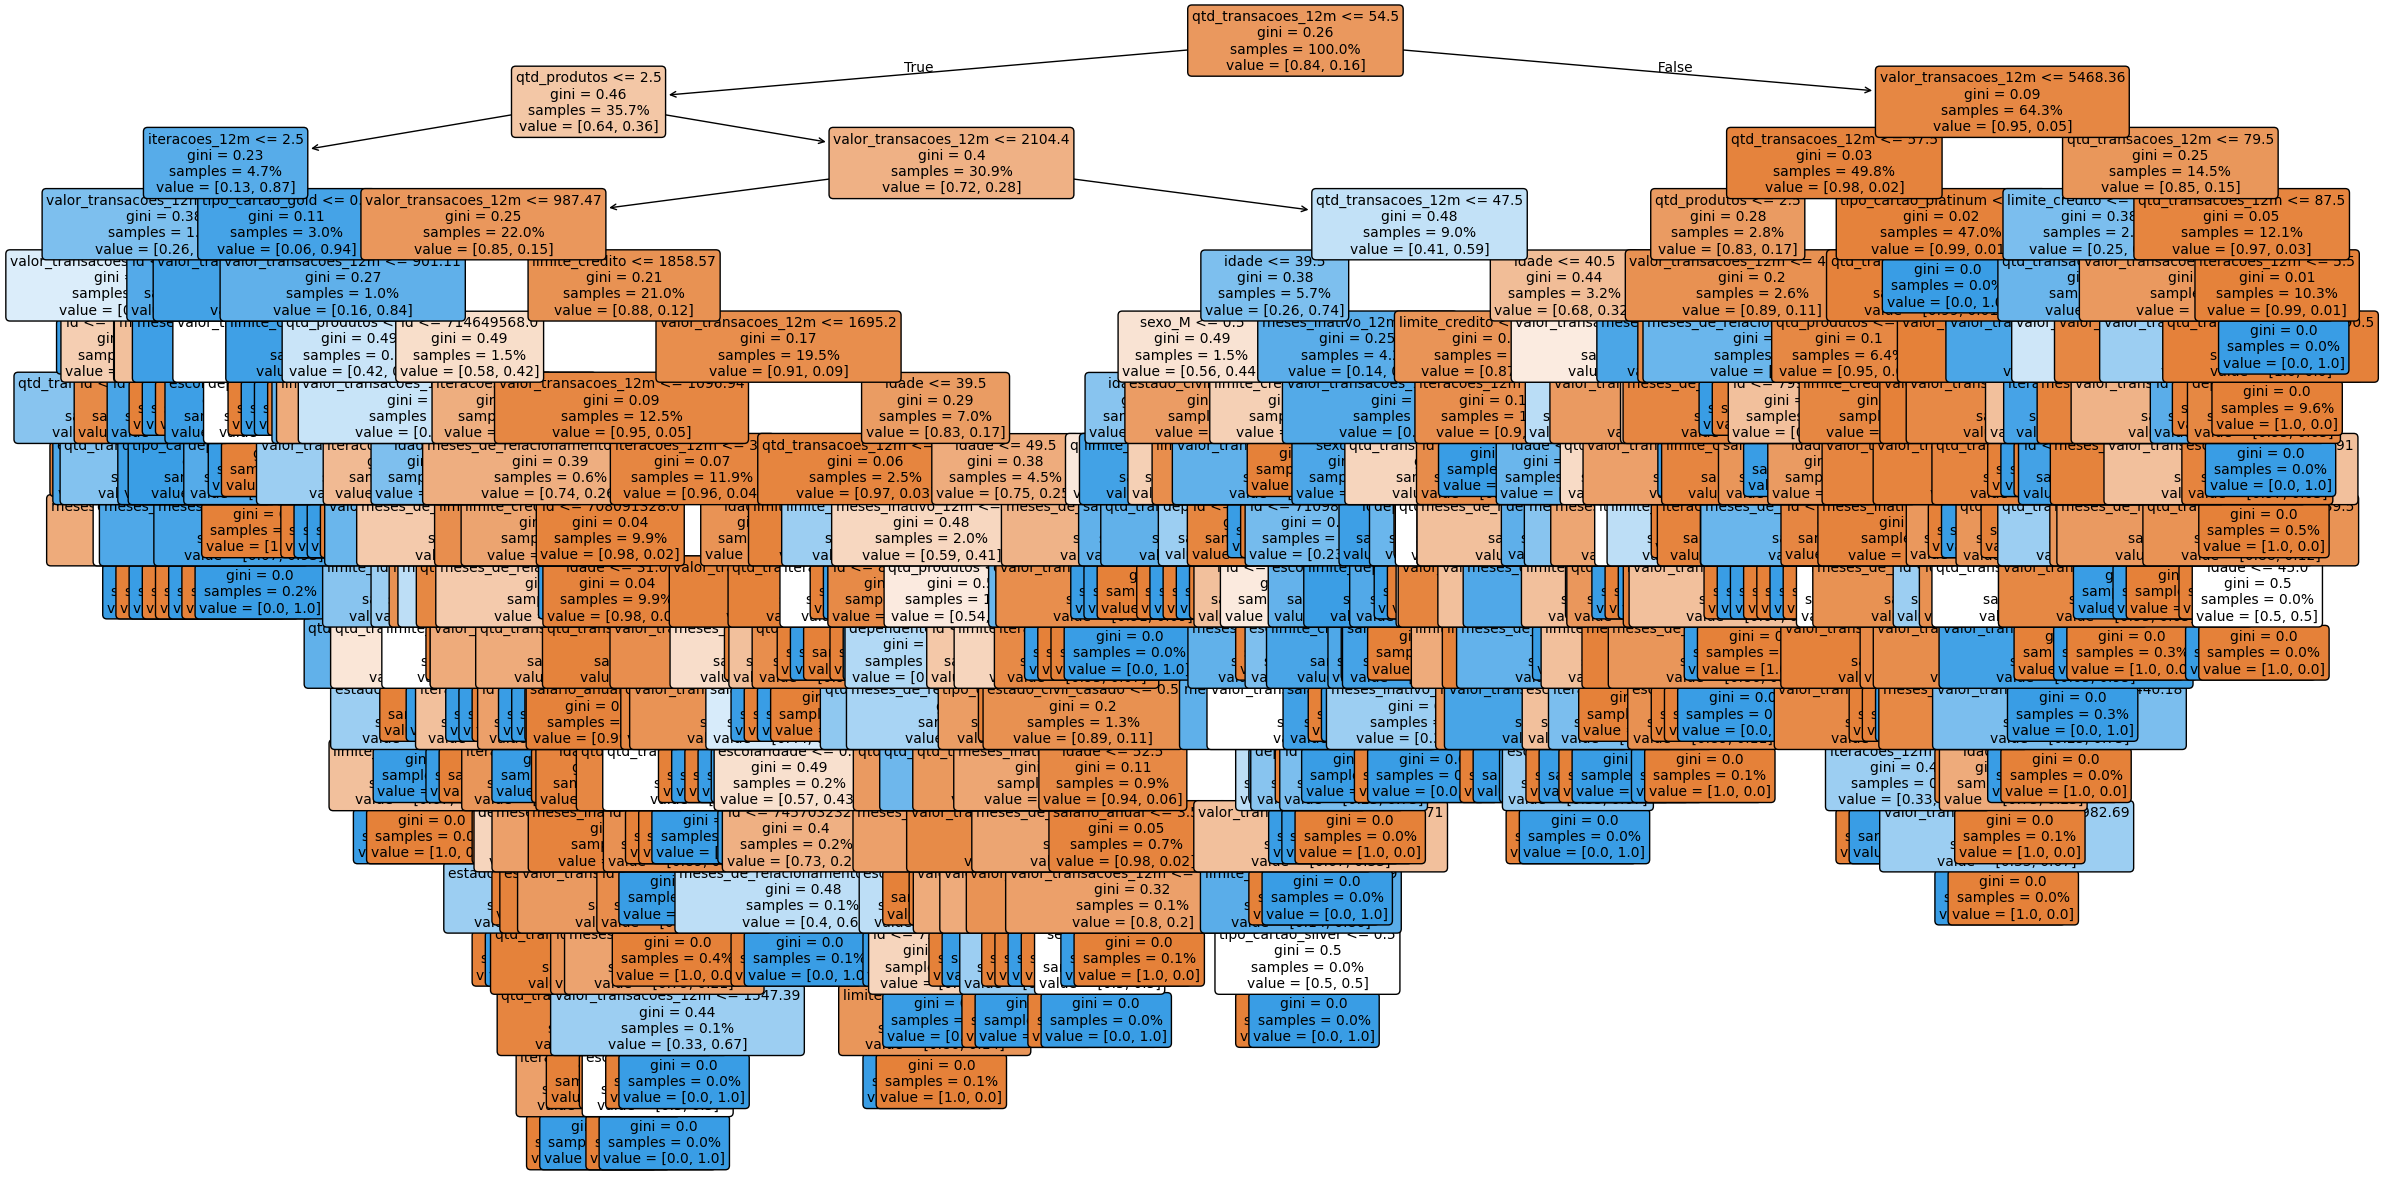

In [79]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(24,12))

plot_tree(
          modelo_arvore,
          filled=True,
          feature_names=x.columns,
          rounded=True,
          fontsize=10,
          proportion=True,
          precision=2
          )

plt.tight_layout()
plt.show()

In [80]:
from sklearn.metrics import accuracy_score

acuracia_teste = accuracy_score(y_teste, Predicoes)
print(f'Acurácia nos dados de teste: {acuracia_teste:.2%}')

Acurácia nos dados de teste: 90.90%


In [81]:
predicoes_treino = modelo_arvore.predict(X_treino)

acuracia_treino = accuracy_score(y_treino, predicoes_treino)
print(f'Acurácia nos dados de treino: {acuracia_treino:.2%}')

Acurácia nos dados de treino: 100.00%


In [82]:
from sklearn.metrics import classification_report

print(classification_report(y_teste, Predicoes))

              precision    recall  f1-score   support

  adimplente       0.95      0.94      0.95      1194
inadimplente       0.70      0.73      0.72       223

    accuracy                           0.91      1417
   macro avg       0.83      0.83      0.83      1417
weighted avg       0.91      0.91      0.91      1417



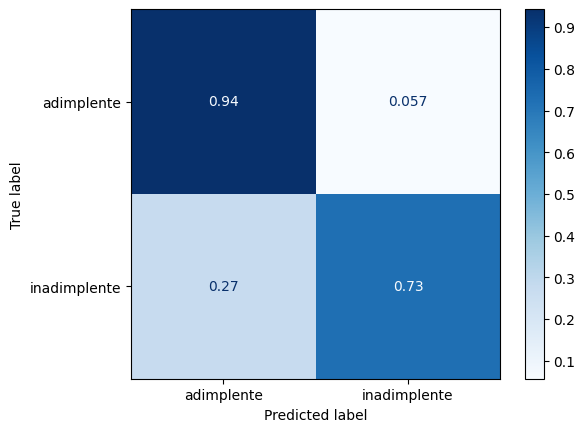

In [83]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(modelo_arvore, X_teste, y_teste, normalize='true', cmap='Blues');


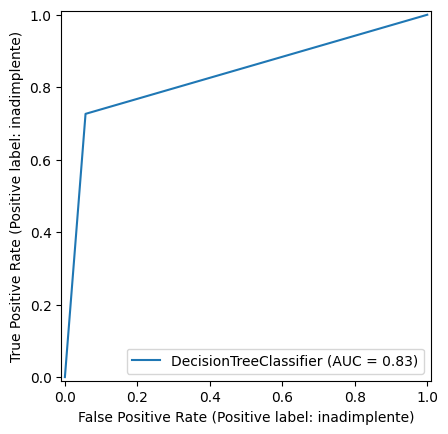

In [84]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(modelo_arvore, X_teste, y_teste);

In [85]:
#para tentar melhorar meu modelo, vou podar a minha arvora, uma vez que ela tendo uma profundidade muito grande, o modelo tente ao overfiting
#já que ela aprende detalhes muito especificos dos dados de treino e acaba perdendo sua capacidade de generalização

modelo_arvore_podada = DecisionTreeClassifier(random_state=42, max_depth=5)

In [86]:
modelo_arvore_podada.fit(X_treino, y_treino)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [87]:
Predicoes_podada = modelo_arvore_podada.predict(X_teste)

In [88]:
#Calculo as probabilidades
probabilidades_podada = modelo_arvore_podada.predict_proba(X_teste)

probabilidades_podada

array([[0.9965812 , 0.0034188 ],
       [0.99869395, 0.00130605],
       [0.99869395, 0.00130605],
       ...,
       [0.95121951, 0.04878049],
       [0.9965812 , 0.0034188 ],
       [0.99869395, 0.00130605]])

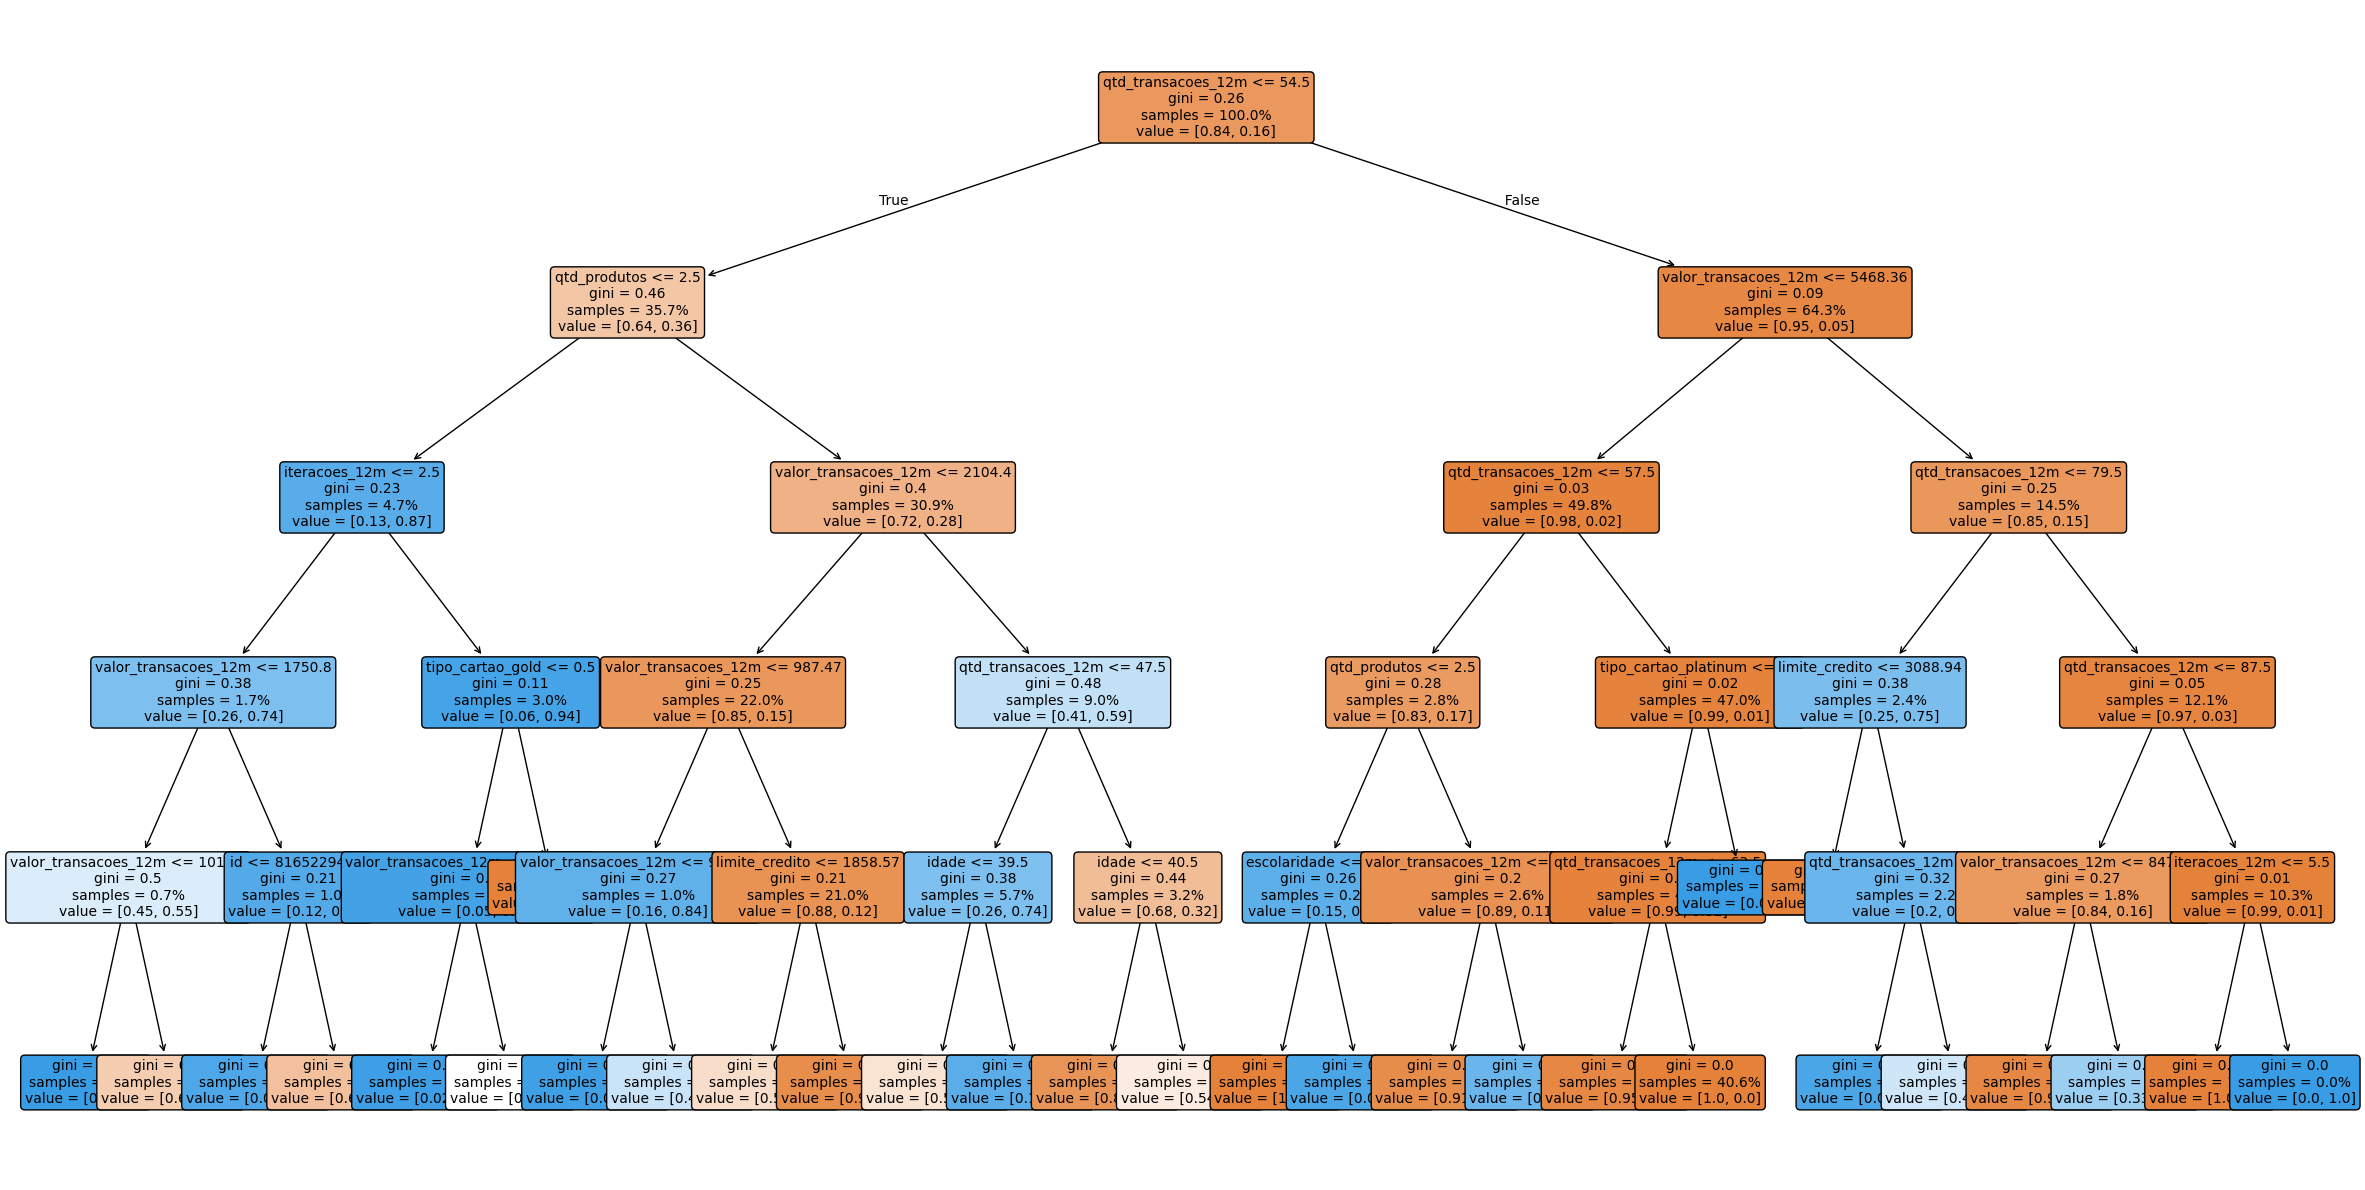

In [89]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(24,12))

plot_tree(
          modelo_arvore_podada,
          filled=True,
          feature_names=x.columns,
          rounded=True,
          fontsize=10,
          proportion=True,
          precision=2
          )

plt.tight_layout()
plt.show()

In [90]:
from sklearn.metrics import accuracy_score

acuracia_teste_podada = accuracy_score(y_teste, Predicoes_podada)
print(f'Acurácia nos dados de teste: {acuracia_teste_podada:.2%}')

Acurácia nos dados de teste: 93.08%


In [91]:
predicoes_treino_podada = modelo_arvore_podada.predict(X_treino)

acuracia_treino_podada = accuracy_score(y_treino, predicoes_treino_podada)
print(f'Acurácia nos dados de treino: {acuracia_treino_podada:.2%}')

Acurácia nos dados de treino: 93.34%


In [92]:
from sklearn.metrics import classification_report

print(classification_report(y_teste, Predicoes_podada))

              precision    recall  f1-score   support

  adimplente       0.94      0.98      0.96      1194
inadimplente       0.87      0.65      0.75       223

    accuracy                           0.93      1417
   macro avg       0.91      0.82      0.85      1417
weighted avg       0.93      0.93      0.93      1417



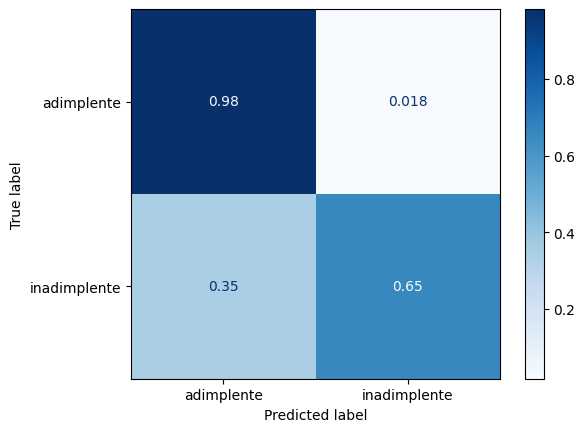

In [93]:
ConfusionMatrixDisplay.from_estimator(modelo_arvore_podada, X_teste, y_teste, normalize='true', cmap='Blues');


In [94]:
from sklearn.model_selection import cross_val_score

modelo_validacao = DecisionTreeClassifier(random_state=42, max_depth=5)
scores = cross_val_score(modelo_validacao, x, y, cv=5, scoring='accuracy')
scores


array([0.71559633, 0.88418079, 0.9180791 , 0.93855932, 0.85805085])

In [95]:
print("O resultado da média das acuracias é %0.2f%% com desvio padrão de %0.2f%%"
% (scores.mean() * 100, scores.std() * 100))

O resultado da média das acuracias é 86.29% com desvio padrão de 7.87%


In [96]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

validacao_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(modelo_validacao, x, y, cv=validacao_cruzada, scoring='accuracy')
scores

array([0.92942837, 0.93149718, 0.92372881, 0.92655367, 0.92161017])

In [97]:
print("O resultado da validação cruzada é %0.2f%% acurácia com desvio padrão de %0.2f%%"
      % (scores.mean() * 100, scores.std() * 100))

O resultado da validação cruzada é 92.66% acurácia com desvio padrão de 0.36%


In [98]:
from sklearn.model_selection import GridSearchCV

In [99]:

# Define a grade de hiperparâmetros que será testada
grade_parametros = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Cria uma instância da Árvore de Decisão
modelo_arvore_grid = DecisionTreeClassifier(random_state=42)

# Configura o Grid Search
# Utiliza a acurácia como métrica de avaliação e validação cruzada com 5 partições
grid_search = GridSearchCV(
    estimator=modelo_arvore_grid,
    param_grid=grade_parametros,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Executa a busca pelos melhores hiperparâmetros
grid_search.fit(x, y)

# Exibe os melhores hiperparâmetros encontrados e a melhor acurácia média
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor acurácia média na validação cruzada: {grid_search.best_score_:.2f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Melhores parâmetros encontrados: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 20}
Melhor acurácia média na validação cruzada: 0.89


In [100]:
modelo_arvore_otimizada = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=10, min_samples_leaf=20)

In [101]:
modelo_arvore_otimizada.fit(X_treino, y_treino)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=20,
                       random_state=42)

In [102]:
predicoes_otimizada=modelo_arvore_otimizada.predict(X_teste)

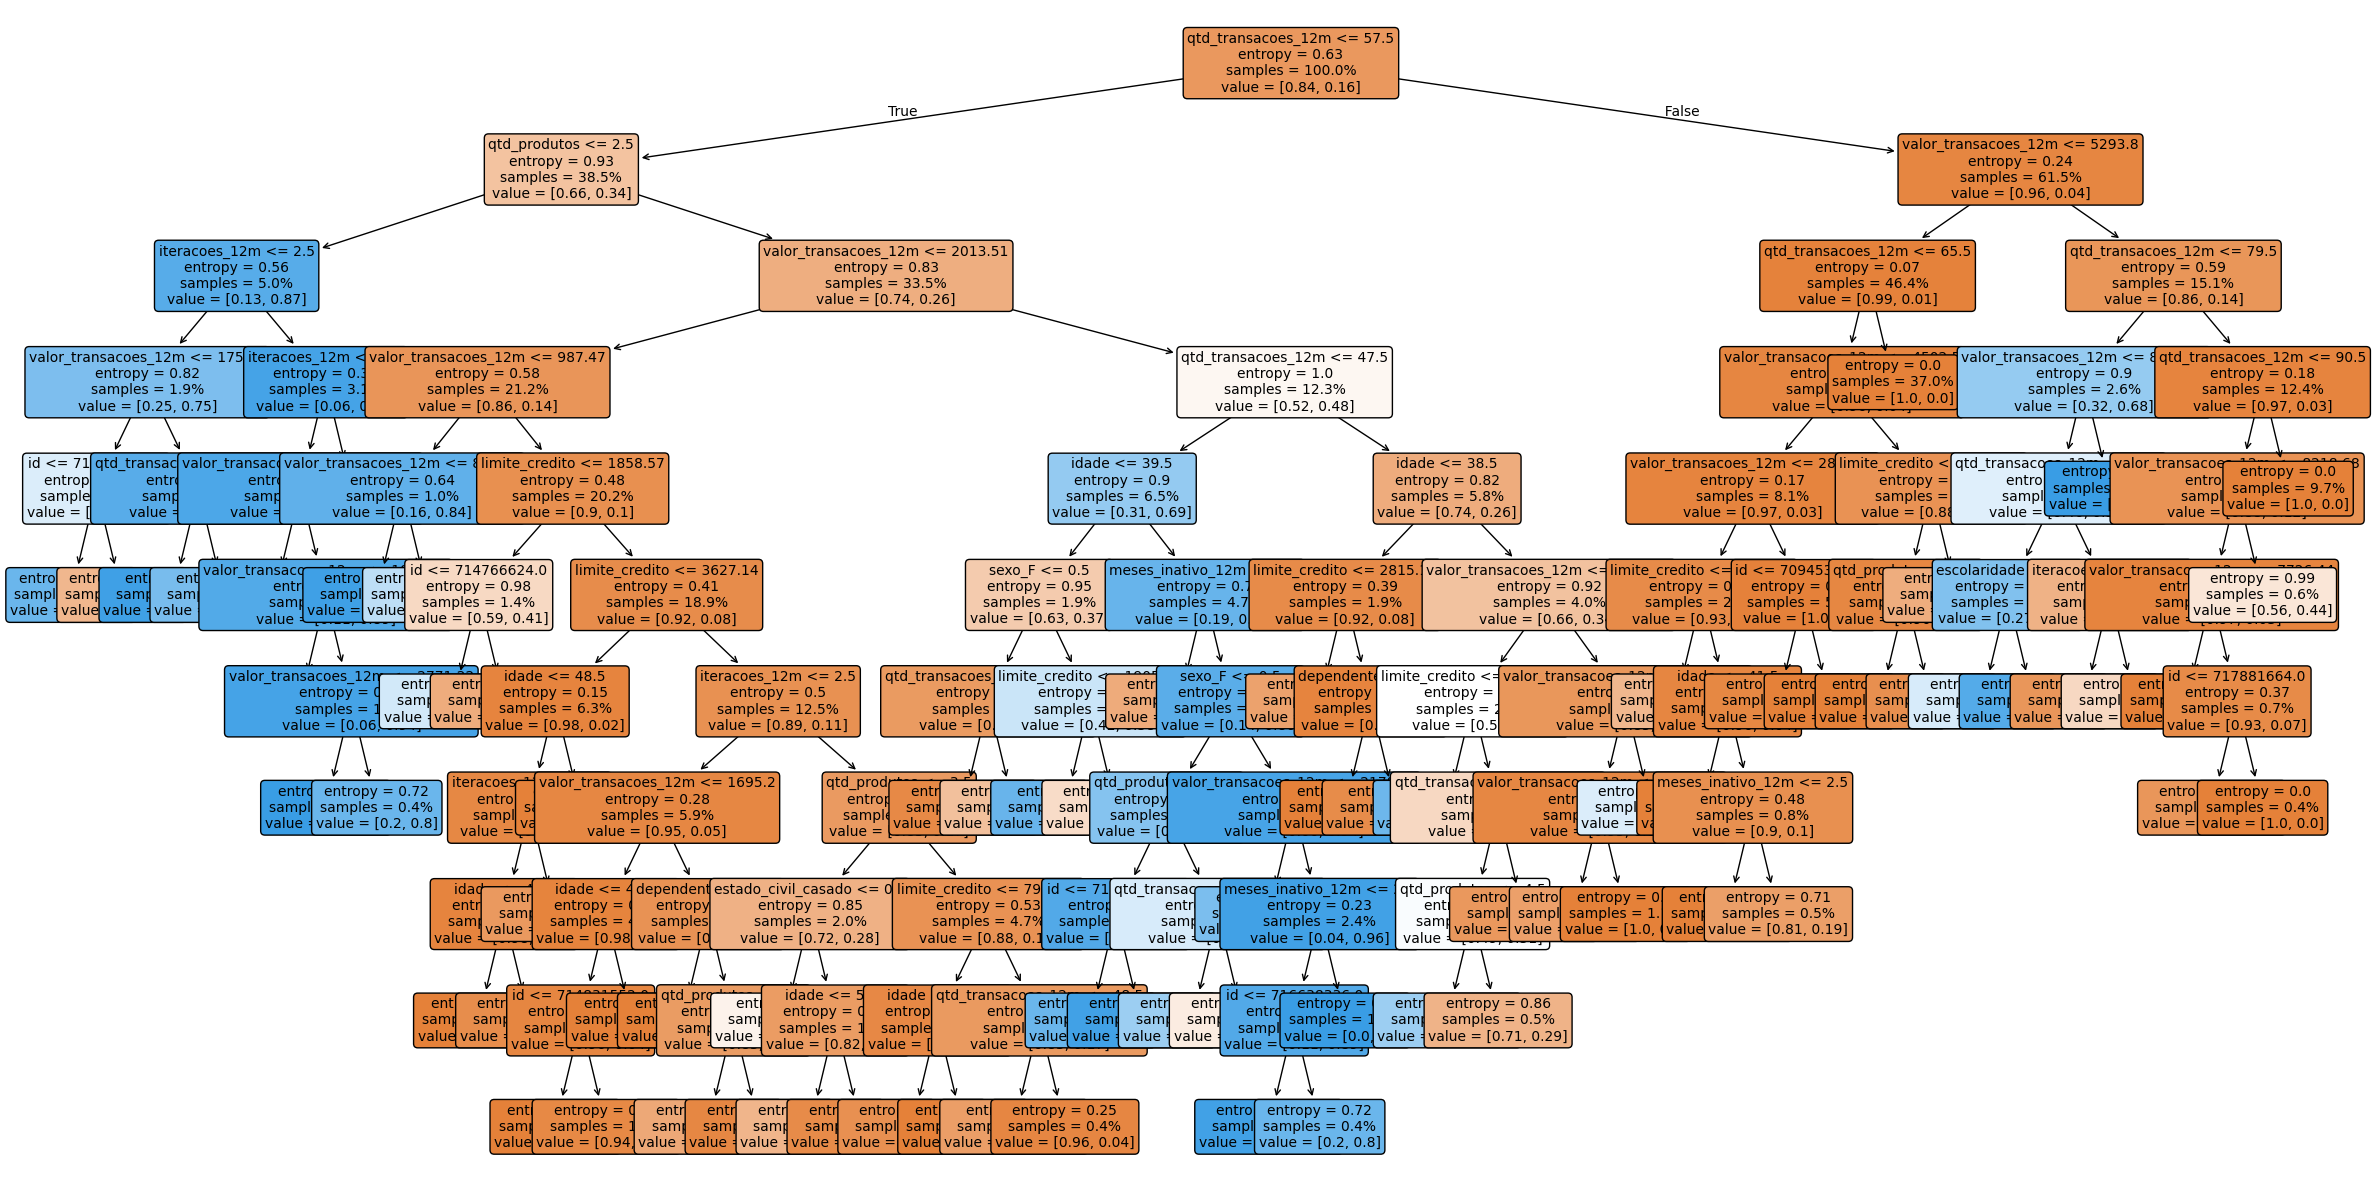

In [103]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(24,12))

plot_tree(
          modelo_arvore_otimizada,
          filled=True,
          feature_names=x.columns,
          rounded=True,
          fontsize=10,
          proportion=True,
          precision=2
          )

plt.tight_layout()
plt.show()

In [104]:

# Prever o Target do conjunto de treinamento
predicoes_treino_otimizada = modelo_arvore_otimizada.predict(X_treino)

# Calcular a acurácia no conjunto de treinamento
acuracia_treino_otimizada = accuracy_score(y_treino, predicoes_treino_otimizada )
print(f'Acurácia nos dados de treino (árvore ajustada): {acuracia_treino_otimizada:.2%}')

# Acurácia no conjunto de teste
acuracia_teste_otimizada  = accuracy_score(y_teste, predicoes_otimizada)
print(f'Acurácia nos dados de teste (árvore ajustada): {acuracia_teste_otimizada:.2%}')

Acurácia nos dados de treino (árvore ajustada): 94.07%
Acurácia nos dados de teste (árvore ajustada): 92.94%


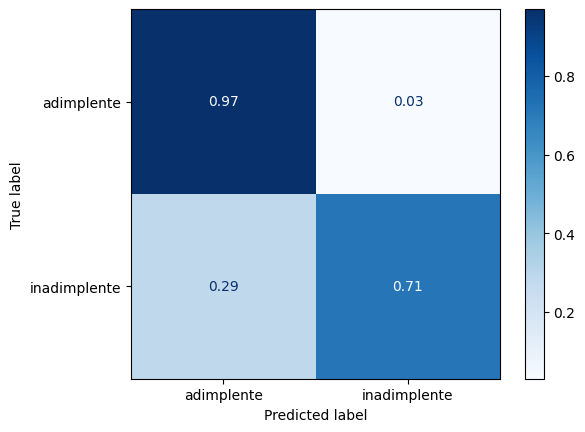

In [105]:

ConfusionMatrixDisplay.from_estimator(modelo_arvore_otimizada,
                                      X_teste, y_teste,
                                      normalize = 'true',
                                      cmap = 'Blues');

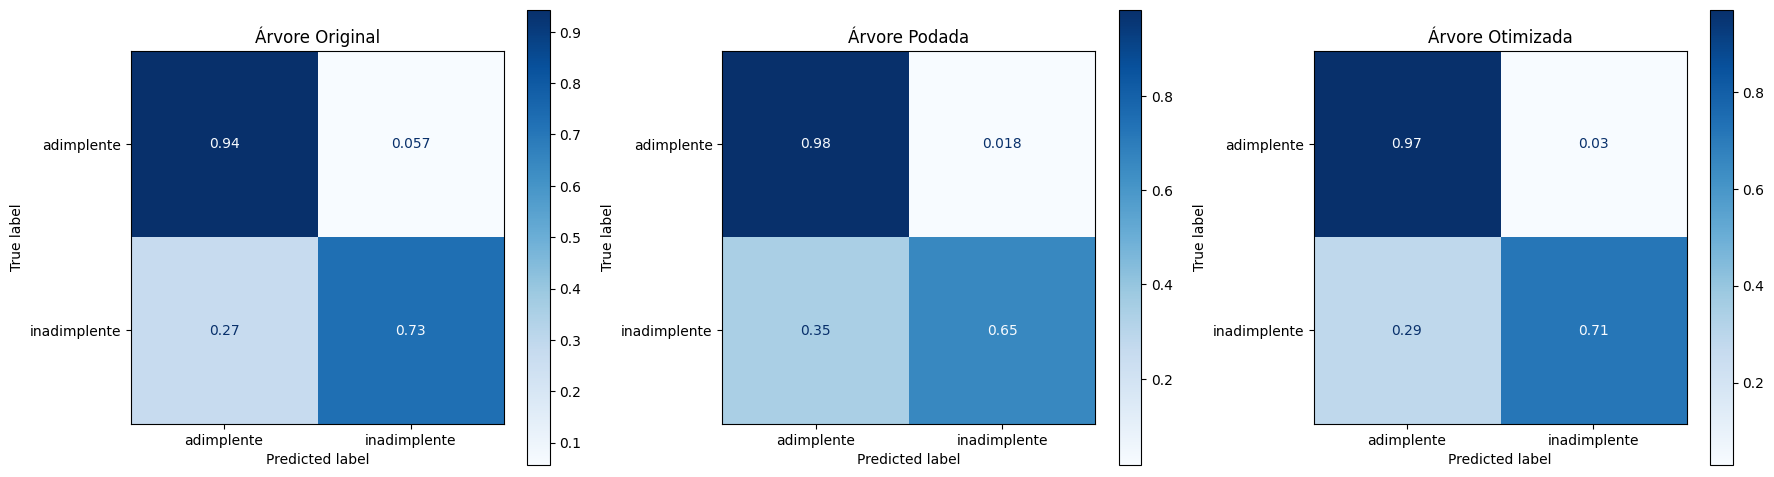

In [107]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_estimator(
    modelo_arvore,
    X_teste,
    y_teste,
    normalize='true',
    cmap='Blues',
    ax=ax[0]
)
ax[0].set_title('Árvore Original')

ConfusionMatrixDisplay.from_estimator(
    modelo_arvore_podada,
    X_teste,
    y_teste,
    normalize='true',
    cmap='Blues',
    ax=ax[1]
)
ax[1].set_title('Árvore Podada')

ConfusionMatrixDisplay.from_estimator(
    modelo_arvore_otimizada,
    X_teste,
    y_teste,
    normalize='true',
    cmap='Blues',
    ax=ax[2]
)
ax[2].set_title('Árvore Otimizada')

plt.tight_layout()
plt.show()

Conclusão: para a arvore original, os resultados do modelo indicaram overfitting. Provavelmente devido a complexidade do modelo, que, sem restrição de profundidade, incorreu na aquisição caracteristicas particulares dos dados de treino.

Inicialmente, podamos a árvore, reduzindo a distância entre os resultados de treino e teste segundo a métrica de acurácia, indicando uma redução do overfitting e uma melhor capacidade de generalização do modelo. Quando avaliamos a matriz de confusão, o modelo melhorou na classificação dos clientes adimplentes, no entanto, reduziu a identificação dos inadimplentes.

Pensando na robustez do modelo podado, rodamos também um cross validation,dividindo os dados em 5 partes e alternando a parcela utilizada para validação.Além de manter a proporção das classes de indimplentes e adimplenetes com a ferramenta 'StratifiedKFold' e'embaralha-los com o parâmetro 'shuffle', para garantir que os 20% destinados para o teste não foram adquiridos por sorte.

No resultado das 5 divisões da validação cruzada, apenas com a cross_val_score, a acurácia média do modelo deu 86,29%. Já com 'StratifiedKFold' e 'shuffle', o modelo apresentou em média 92,66% de acurácia, se aproximando melhor do conjunto de teste original da arvore já podada, onde obtive 93,08%.

Avançamos um terceiro passo que diz respeito a otimização do modelo usando a função GridSearchCV, para encontrar os melhores hiperparametros. Houve uma pequena piora na acuracia do modelo, no entanto, melhora na matriz de confusão.

O próximo passo será utilizar a biblioteeca Random Forest, menos sujeita a overtifiting, com mais hiperparametros para controlarmos e, principalmente, com menos variância.